In [1]:
import numpy as np
from sim_library.simulation import simulate_pulses_single_atom
from sim_library.sequences import  RR3_gate
from sim_library.plotting import  display_table_compare
from scipy.constants import hbar, pi
from sim_library.constants import k_eff, dR, m, omega_eg, kb
import matplotlib.pyplot as plt

In [5]:
# rabi_freq = 2*pi*1e5
# rabi_time = 2*pi/rabi_freq

# omega_time = 2*pi/omega_eg #chosen to be much larger than recoil shift

time_steps = 1



p_min = -16
p_max = 16
basis = np.arange(p_min, p_max + 1)

initial_state = np.zeros(shape=(8,len(basis)), dtype=np.complex128)
target = np.zeros(shape=(8,len(basis)), dtype=np.complex128)

initial_state[0,8] = 1
initial_state[1, 10] = 1
initial_state[2, 12] = 1
initial_state[3, 14] = 1
initial_state[4, 16] = 1
initial_state[5, 18] = 1
initial_state[6, 20] = 1
initial_state[7, 22] = 1

target[0,8] = 1
target[1,9] = 1
target[2,10] = 1
target[3,11] = 1
target[4,16] = 1
target[5,17] = 1
target[6,18] = 1
target[7,19] = 1


# rabi_freqs = 2*pi*np.logspace(5, 9, 1000)
rabi_freqs = np.linspace(2*pi*1e6,2*pi*5e7,500)
fidelities = np.zeros((8,len(rabi_freqs)))

for j in range(8):
    for i, rabi in enumerate(rabi_freqs):

        RR3 = RR3_gate(rabi_freq=rabi, time_steps=time_steps)

        wave_func, times = simulate_pulses_single_atom(pulse_seq= RR3, basis= basis, initial_state=initial_state[j,:], d_shift=0)

        final = wave_func[-1,:]
        final = final/np.linalg.norm(final)

        fidelity = np.sum(np.abs(target[j,:])*np.abs(final))**2
        fidelities[j,i] = fidelity

# fig, ax = plt.subplots()


In [59]:

b = np.ones(3)
c = np.zeros((2,3))
c[0] = b
print(c)

c = np.mean(c, axis=0)
print(c)

[[1. 1. 1.]
 [0. 0. 0.]]
[0.5 0.5 0.5]


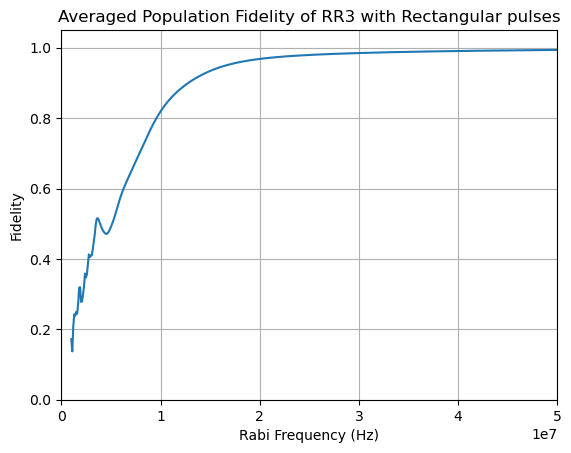

In [11]:
avg_fids = np.mean(fidelities, axis=0)

plt.plot(rabi_freqs/(2*pi), avg_fids)
plt.grid(axis='both')
plt.xlim(0,5e7)
plt.ylim(0,1.05)
plt.ylabel('Fidelity')
plt.xlabel('Rabi Frequency (Hz)')
plt.title(rf'Averaged Population Fidelity of RR3 with Rectangular pulses')
plt.title
plt.show()
# print(fidelities)

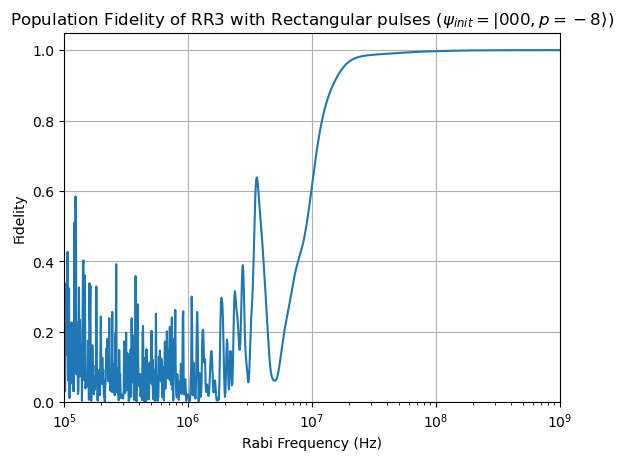

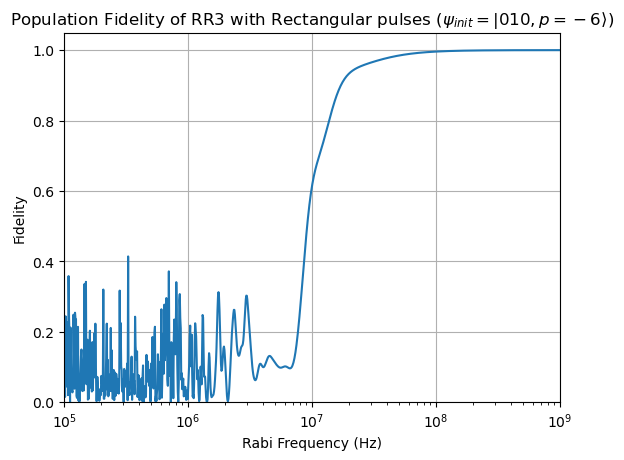

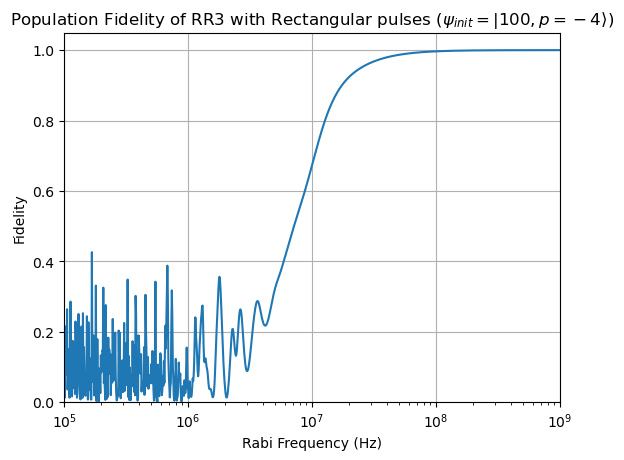

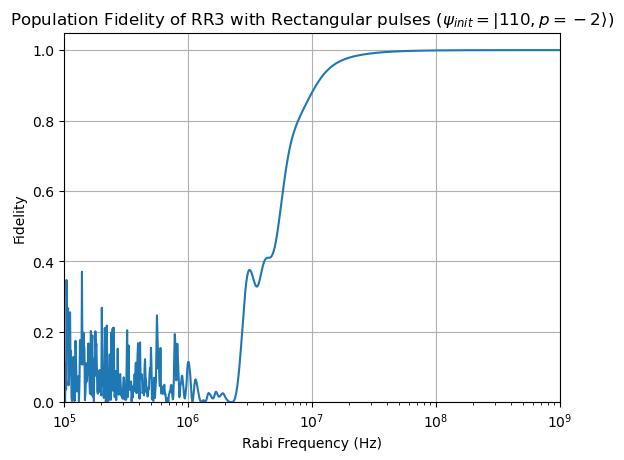

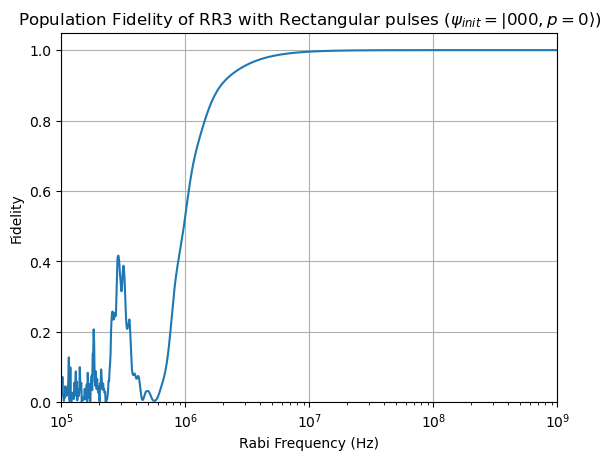

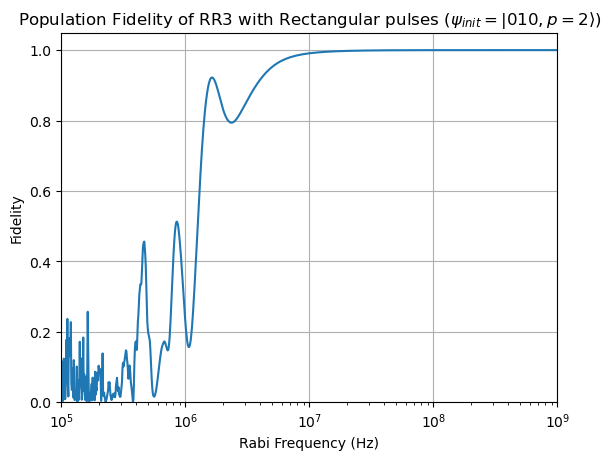

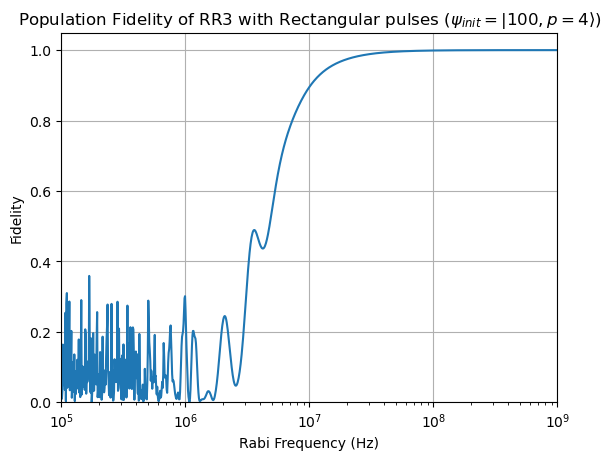

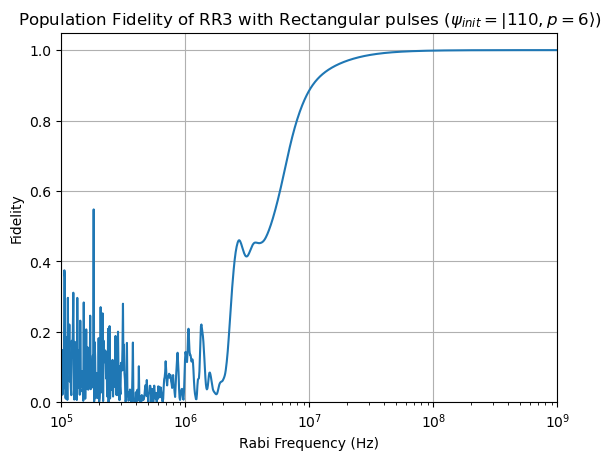

In [55]:
title_text = [r'|000,p=-8\rangle', r'|010,p=-6\rangle', r'|100,p=-4\rangle', r'|110,p=-2\rangle', r'|000,p=0\rangle', r'|010,p=2\rangle', r'|100,p=4\rangle', r'|110,p=6\rangle']
for i in range(8):
    plt.semilogx(rabi_freqs/(2*pi), fidelities[i])
    plt.grid(axis='both')
    plt.xlim(1e5,1e9)
    plt.ylim(0,1.05)
    plt.ylabel('Fidelity')
    plt.xlabel('Rabi Frequency (Hz)')
    plt.title(rf'Population Fidelity of RR3 with Rectangular pulses ($\psi_{{init}}={title_text[i]}$)')
    plt.title
    plt.show()
    # print(fidelities)


In [43]:
initial_state = np.zeros(shape=(3,5), dtype=np.complex128)
print(initial_state)
print(initial_state[0,:])

[[0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]]
[0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
